# 06 – Evaluation and Results

## Mục tiêu

Notebook này tổng hợp **kết quả đánh giá (Evaluation)** và **diễn giải kết quả (Results)** của toàn bộ pipeline phân tích Attrition, bao gồm:

- 🤖 **Modeling**: Đánh giá và so sánh các mô hình dự đoán nhân viên nghỉ việc  
- 🔍 **Mining**: Phân tích nguyên nhân nghỉ việc thông qua các cụm luật kết hợp  

### Mục tiêu chính
- Sử dụng **metric phù hợp với dữ liệu mất cân bằng**
- So sánh mô hình theo **hiệu quả dự đoán và chi phí huấn luyện**
- Kết nối kết quả mô hình với **phân tích nguyên nhân**
- Định hướng **ứng dụng thực tế cho bộ phận HR**

## 6.1. Evaluation Strategy & Metrics

Bài toán Attrition là bài toán **phân loại mất cân bằng**, trong đó:
- Lớp **Leave (1)** chiếm tỷ lệ nhỏ
- Lớp **Stay (0)** chiếm đa số

➡️ Vì vậy, **Accuracy không phản ánh đúng hiệu quả mô hình**, do mô hình có thể đạt accuracy cao chỉ bằng cách dự đoán tất cả là *Stay*.

### Chiến lược đánh giá
- Tập trung vào **hiệu quả trên lớp Leave**
- So sánh mô hình dưới **nhiều góc độ**, không chỉ một metric

### Các metric được sử dụng
- **Recall (Leave)**  
  → Mức độ mô hình phát hiện được nhân viên thực sự nghỉ việc  

- **Precision (Leave)**  
  → Độ tin cậy của các cảnh báo nghỉ việc  

- **F1-score (Leave)**  
  → Cân bằng giữa Recall và Precision  

- **PR-AUC**  
  → Đánh giá khả năng xếp hạng rủi ro trong dữ liệu mất cân bằng  

- **Training Time**  
  → Chi phí tính toán và khả năng triển khai thực tế

## 6.2. Load Modeling Results

Trong phần này, các kết quả huấn luyện của **XGBoost** và **Random Forest** được tải từ các file JSON đã lưu trước đó.

Các file này bao gồm:
- Các metric đánh giá chính (PR-AUC, Recall, Precision, F1-score)
- Thời gian huấn luyện
- Thông tin phục vụ so sánh mô hình

Việc tách riêng bước lưu và bước load giúp:
- So sánh mô hình dễ dàng
- Tái sử dụng kết quả
- Giữ notebook Evaluation gọn và rõ ràng

In [17]:
import json
import pandas as pd
from pathlib import Path

# ---- 1. Define base directory for saved results ----
RESULTS_DIR = Path("../data/processed/models")   # có thể đổi thành "outputs/models" nếu cần

XGB_METRICS_PATH = RESULTS_DIR / "xgb/xgb_metrics.json"
RF_METRICS_PATH  = RESULTS_DIR / "rf/rf_metrics.json"

# ---- 2. Load metrics from files ----
with open(XGB_METRICS_PATH, "r") as f:
    xgb = json.load(f)

with open(RF_METRICS_PATH, "r") as f:
    rf = json.load(f)

# ---- 3. Create comparison table ----
df_models = pd.DataFrame([
    {
        "Model": "XGBoost",
        "PR-AUC": xgb["pr_auc"],
        "Recall (Leave)": xgb.get("recall_leave"),
        "Precision (Leave)": xgb.get("precision_leave"),
        "F1-score (Leave)": xgb.get("f1_leave"),
        "Train Time (s)": xgb["train_time_sec"]
    },
    {
        "Model": "Random Forest",
        "PR-AUC": rf["pr_auc"],
        "Recall (Leave)": rf.get("recall_leave"),
        "Precision (Leave)": rf.get("precision_leave"),
        "F1-score (Leave)": rf.get("f1_score"),
        "Train Time (s)": rf["train_time_sec"]
    }
])

df_models

,Model,PR-AUC,Recall (Leave),Precision (Leave),F1-score (Leave),Train Time (s)
0,XGBoost,0.643196,0.708333,0.350515,0.468966,0.370739
1,Random Forest,0.556644,0.770833,0.397849,0.524823,0.612335


## 6.3. Model Comparison – Quantitative Results

Bảng kết quả cho thấy **sự đánh đổi (trade-off)** rõ ràng giữa các mô hình:

- Không tồn tại mô hình nào tối ưu trên **mọi metric**
- Mỗi mô hình phù hợp với **mục tiêu nghiệp vụ khác nhau**

### Nhận xét
- **Random Forest** phát hiện được nhiều ca nghỉ việc hơn (Recall cao)
- **XGBoost** có khả năng **xếp hạng rủi ro tổng thể tốt hơn** (PR-AUC cao)
- Không tồn tại mô hình “tốt tuyệt đối” cho mọi mục tiêu

## 6.4. Visualization – Model Comparison

Các biểu đồ được sử dụng để trực quan hóa sự khác biệt giữa các mô hình:

- Biểu đồ **Recall vs F1-score** cho thấy khả năng phát hiện và độ cân bằng của từng mô hình
- Biểu đồ **PR-AUC** thể hiện khả năng xếp hạng rủi ro trong bối cảnh dữ liệu mất cân bằng

Việc trực quan hóa giúp:
- So sánh nhanh hiệu quả mô hình
- Hỗ trợ ra quyết định lựa chọn mô hình trong thực tế

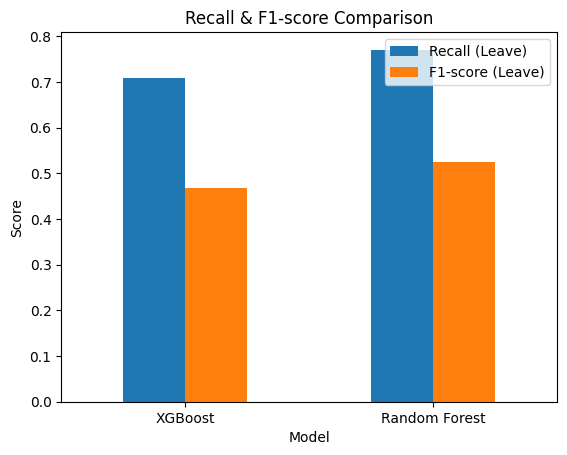

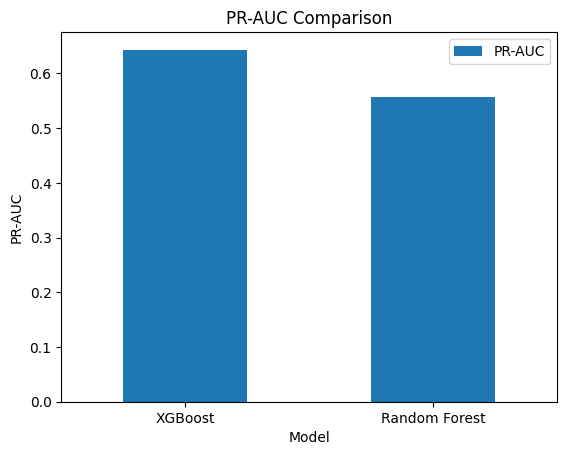

In [18]:
import matplotlib.pyplot as plt

# Recall vs F1-score
df_models.set_index("Model")[["Recall (Leave)", "F1-score (Leave)"]].plot(kind="bar")
plt.title("Recall & F1-score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# PR-AUC comparison
df_models.set_index("Model")[["PR-AUC"]].plot(kind="bar")
plt.title("PR-AUC Comparison")
plt.ylabel("PR-AUC")
plt.xticks(rotation=0)
plt.show()

## 6.5. Modeling Results – Interpretation

### 🔹 Random Forest
- Recall (Leave) **cao nhất (0.77)**
- Phát hiện tốt các nhân viên có nguy cơ nghỉ việc
- Phù hợp cho **cảnh báo sớm (early warning system)**

**Hạn chế:**  
- Precision chưa cao → có thể tạo nhiều cảnh báo dư thừa

---

### 🔹 XGBoost
- PR-AUC **cao nhất (0.64)**
- Khả năng **xếp hạng mức độ rủi ro** hiệu quả
- Phù hợp để **ưu tiên nguồn lực HR** cho nhóm nguy cơ cao nhất

➡️ Lựa chọn mô hình cần dựa trên **mục tiêu sử dụng thực tế**, không chỉ dựa vào một metric đơn lẻ.

## 6.6. Mining Results – Cluster-based Insights

Sau bước Rule Mining, các luật dẫn đến nghỉ việc được phân cụm nhằm:

- Nhóm các luật có đặc điểm tương đồng
- Hiểu rõ các **kiểu nguyên nhân nghỉ việc khác nhau**
- Hỗ trợ chuyển kết quả phân tích thành hành động cụ thể cho HR

Tổng cộng, các luật Attrition được phân thành **7 cụm (clusters)**.

In [19]:

import pandas as pd

rules = pd.read_csv("../data/processed/leave_rules_clusters.csv")

print("Số luật:", rules.shape[0])
print("Số cụm:", rules["cluster"].nunique())

rules.head(7)


Số luật: 100
Số cụm: 7


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,rule_name,antecedent_items,n_items,cluster
0,"frozenset({'MonthlyIncome_bin_(0, 3000]', 'Att...","frozenset({'YearsAtCompany_bin_(0, 2]', 'JobLe...",0.045270,0.066216,0.025,0.552239,8.339933,1.0,0.022002,2.085450,0.921826,0.289062,0.520487,0.464895,"MonthlyIncome_bin_(0, 3000], AttritionLabel_Le...","[""frozenset('MonthlyIncome_bin_(0"", ""3000]'"", ...",5,5
1,"frozenset({'YearsAtCompany_bin_(0, 2]', 'JobLe...","frozenset({'MonthlyIncome_bin_(0, 3000]', 'Att...",0.066216,0.045270,0.025,0.377551,8.339933,1.0,0.022002,1.533828,0.942504,0.289062,0.348036,0.464895,"YearsAtCompany_bin_(0, 2], JobLevel_1, Age_bin...","[""frozenset('YearsAtCompany_bin_(0"", ""2]'"", ""'...",5,0
2,"frozenset({'MonthlyIncome_bin_(0, 3000]', 'Yea...","frozenset({'AttritionLabel_Leave', 'JobLevel_1...",0.057432,0.054054,0.025,0.435294,8.052941,1.0,0.021896,1.675113,0.929187,0.289062,0.403025,0.448897,"MonthlyIncome_bin_(0, 3000], YearsAtCompany_bi...","[""frozenset('MonthlyIncome_bin_(0"", ""3000]'"", ...",6,1
3,"frozenset({'AttritionLabel_Leave', 'JobLevel_1...","frozenset({'MonthlyIncome_bin_(0, 3000]', 'Yea...",0.054054,0.057432,0.025,0.462500,8.052941,1.0,0.021896,1.753614,0.925869,0.289062,0.429749,0.448897,"AttritionLabel_Leave, JobLevel_1, TotalWorking...","[""frozenset('AttritionLabel_Leave'"", ""'JobLeve...",4,2
4,"frozenset({'MonthlyIncome_bin_(0, 3000]', 'Att...","frozenset({'YearsAtCompany_bin_(0, 2]', 'Age_b...",0.045270,0.072297,0.025,0.552239,7.638443,1.0,0.021727,2.071869,0.910292,0.270073,0.517344,0.449017,"MonthlyIncome_bin_(0, 3000], AttritionLabel_Le...","[""frozenset('MonthlyIncome_bin_(0"", ""3000]'"", ...",5,5
5,"frozenset({'MonthlyIncome_bin_(0, 3000]', 'Att...","frozenset({'YearsAtCompany_bin_(0, 2]', 'Age_b...",0.045270,0.072297,0.025,0.552239,7.638443,1.0,0.021727,2.071869,0.910292,0.270073,0.517344,0.449017,"MonthlyIncome_bin_(0, 3000], AttritionLabel_Le...","[""frozenset('MonthlyIncome_bin_(0"", ""3000]'"", ...",6,5
6,"frozenset({'YearsAtCompany_bin_(0, 2]', 'Age_b...","frozenset({'MonthlyIncome_bin_(0, 3000]', 'Att...",0.072297,0.045270,0.025,0.345794,7.638443,1.0,0.021727,1.459373,0.936812,0.270073,0.314774,0.449017,"YearsAtCompany_bin_(0, 2], Age_bin_(18, 30] → ...","[""frozenset('YearsAtCompany_bin_(0"", ""2]'"", ""'...",4,0


In [20]:
# Phân bố số luật theo cụm
rules["cluster"].value_counts().sort_index()

cluster
0    14
1     9
2    18
3    34
4    10
5    11
6     4
Name: count, dtype: int64

In [21]:
# Trích xuất luật tiêu biểu theo từng cụm
TOP_N = 3

for cid in sorted(rules["cluster"].unique()):
    print(f"\n=== CLUSTER {cid} ===")
    
    top_rules = (
        rules[rules["cluster"] == cid]
        .sort_values(["lift", "confidence"], ascending=False)
        .head(TOP_N)
    )
    
    for _, r in top_rules.iterrows():
        print(
            f"- IF {r['antecedents']} "
            f"→ {r['consequents']} "
            f"(conf={r['confidence']:.2f}, lift={r['lift']:.2f})"
        )



=== CLUSTER 0 ===
- IF frozenset({'YearsAtCompany_bin_(0, 2]', 'JobLevel_1', 'Age_bin_(18, 30]'}) → frozenset({'MonthlyIncome_bin_(0, 3000]', 'AttritionLabel_Leave', 'TotalWorkingYears_bin_(0, 5]'}) (conf=0.38, lift=8.34)
- IF frozenset({'YearsAtCompany_bin_(0, 2]', 'Age_bin_(18, 30]'}) → frozenset({'MonthlyIncome_bin_(0, 3000]', 'AttritionLabel_Leave', 'TotalWorkingYears_bin_(0, 5]'}) (conf=0.35, lift=7.64)
- IF frozenset({'YearsAtCompany_bin_(0, 2]', 'Age_bin_(18, 30]'}) → frozenset({'MonthlyIncome_bin_(0, 3000]', 'AttritionLabel_Leave', 'JobLevel_1', 'TotalWorkingYears_bin_(0, 5]'}) (conf=0.35, lift=7.64)

=== CLUSTER 1 ===
- IF frozenset({'MonthlyIncome_bin_(0, 3000]', 'YearsAtCompany_bin_(0, 2]', 'Age_bin_(18, 30]'}) → frozenset({'AttritionLabel_Leave', 'JobLevel_1', 'TotalWorkingYears_bin_(0, 5]'}) (conf=0.44, lift=8.05)
- IF frozenset({'MonthlyIncome_bin_(0, 3000]', 'YearsAtCompany_bin_(0, 2]', 'Age_bin_(18, 30]'}) → frozenset({'AttritionLabel_Leave', 'TotalWorkingYears_bin_(0,

## 6.7. Insights & Actionable Recommendations from Attrition Clusters

Các cụm nhân viên nghỉ việc (Attrition Clusters) phản ánh những **nhóm rủi ro nghỉ việc điển hình**, trong đó mỗi cụm đại diện cho một tổ hợp đặc điểm phổ biến. Kết quả cho thấy Attrition **không xuất phát từ một yếu tố đơn lẻ**, mà là hệ quả của sự kết hợp giữa **kinh nghiệm, thu nhập, áp lực công việc và giai đoạn nghề nghiệp**. Từ đó, các insight và khuyến nghị hành động được tổng hợp như sau:

---

### 🧩 Cluster 0 – Nhân viên rất mới, vị trí thấp  
**Insight:** Nhân viên nghỉ việc chủ yếu trong 0–2 năm đầu, khi mức độ gắn kết tổ chức còn thấp và vai trò chưa rõ ràng.  
**Khuyến nghị:** Chuẩn hóa chương trình onboarding, gán mentor trong 3–6 tháng đầu và theo dõi sát mức độ hài lòng giai đoạn thử việc.

---

### 🧩 Cluster 1 – Thu nhập thấp ở giai đoạn đầu  
**Insight:** Thu nhập thấp kết hợp với thâm niên ngắn làm gia tăng nguy cơ nghỉ việc do kỳ vọng tài chính không được đáp ứng.  
**Khuyến nghị:** Rà soát lương entry-level, bổ sung đãi ngộ phi tài chính và minh bạch lộ trình tăng lương trong năm đầu.

---

### 🧩 Cluster 2 – Ít kinh nghiệm tổng thể  
**Insight:** Nhân viên thiếu kinh nghiệm tổng thể dễ gặp khó khăn trong thích nghi và đáp ứng yêu cầu công việc.  
**Khuyến nghị:** Thiết kế chương trình đào tạo kỹ năng nền tảng, phân công công việc phù hợp và đánh giá hiệu suất theo lộ trình tăng dần.

---

### 🧩 Cluster 3 – OverTime cao  
**Insight:** OverTime kéo dài là yếu tố kích hoạt Attrition rõ rệt, đặc biệt với nhân viên ít kinh nghiệm.  
**Khuyến nghị:** Kiểm soát khối lượng công việc, giới hạn OverTime cho nhân viên mới và theo dõi sớm dấu hiệu burnout.

---

### 🧩 Cluster 4 – Thiếu kinh nghiệm kết hợp áp lực thời gian  
**Insight:** Sự cộng hưởng giữa thiếu kinh nghiệm và áp lực cao tạo ra rủi ro nghỉ việc đáng kể.  
**Khuyến nghị:** Điều chỉnh kỳ vọng hiệu suất, giảm áp lực song song với đào tạo và duy trì cơ chế phản hồi thường xuyên.

---

### 🧩 Cluster 5 – Thu nhập thấp dù đã có kinh nghiệm  
**Insight:** Nhân viên có kinh nghiệm nhưng thu nhập thấp dễ cảm thấy giá trị đóng góp không được ghi nhận.  
**Khuyến nghị:** Đánh giá lại tính công bằng đãi ngộ, tăng lương theo năng lực và minh bạch tiêu chí thăng tiến.

---

### 🧩 Cluster 6 – Nghỉ việc do nhiều yếu tố nhỏ kết hợp  
**Insight:** Không có yếu tố chi phối nổi trội, Attrition mang tính cá nhân hoặc tổng hợp nhiều nguyên nhân nhỏ.  
**Khuyến nghị:** Thực hiện exit interview chi tiết, kết hợp phân tích định tính với mô hình định lượng và cá nhân hóa chính sách giữ chân.

---

**Tổng kết:** Các cụm cho thấy Attrition là hiện tượng đa chiều, đòi hỏi chiến lược giữ chân nhân sự cần được **thiết kế theo từng nhóm rủi ro cụ thể**, thay vì áp dụng một chính sách chung cho toàn bộ tổ chức.

## 6.8. Linking Modeling & Mining

Hai hướng phân tích bổ trợ cho nhau:

- **Modeling** trả lời câu hỏi:  
  *Nhân viên nào có nguy cơ nghỉ việc?*

- **Mining** trả lời câu hỏi:  
  *Những đặc điểm nào thường đi kèm với việc nghỉ việc?*

Việc kết hợp hai hướng giúp:
- Phát hiện **đúng đối tượng**
- Hiểu **đúng bản chất vấn đề**
- Tránh các quyết định can thiệp cảm tính

## 6.9. Practical Implications for HR

Từ kết quả mô hình và phân tích luật, có thể rút ra một số định hướng ứng dụng:

- 🚨 Sử dụng mô hình dự đoán để **cảnh báo sớm Attrition**
- 🎯 Ưu tiên can thiệp dựa trên **xếp hạng rủi ro**
- 💰 Theo dõi nhóm nhân viên có **thu nhập thấp**
- 🧑‍🏫 Hỗ trợ nhân viên mới thông qua **mentoring & onboarding**
- ⏱ Kiểm soát **OverTime kéo dài**
- 📈 Xây dựng **lộ trình phát triển nghề nghiệp rõ ràng**

➡️ Các khuyến nghị này đóng vai trò **định hướng**, cần được kiểm chứng thêm trong bối cảnh doanh nghiệp thực tế.

## 6.10. Conclusion

Notebook này đã thực hiện:

- Đánh giá mô hình dự đoán Attrition bằng **metric phù hợp với dữ liệu mất cân bằng**
- Chỉ ra **điểm mạnh – điểm yếu** của từng mô hình
- Kết nối kết quả Modeling với Mining để **tăng khả năng diễn giải**
- Định hướng ứng dụng thực tế cho **bài toán quản trị nhân sự**

Trong đó:
- **Random Forest** phù hợp cho phát hiện sớm
- **XGBoost** phù hợp cho xếp hạng rủi ro
- **Rule Mining** giúp chuyển kết quả phân tích thành insight có ý nghĩa nghiệp vụ